In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Explain what X and y represent.
## x دي مساحه البيت 
## y دا سعره (زي ما مكتوب في الكومنت)=(ولو زي المحاضره فا y=wx+b)

In [34]:
X = [50, 60, 70, 80, 90]
y = [150, 180, 210, 240, 270]

## 2. Convert the data to numpy arrays.

In [35]:
X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

In [36]:
class LinearRegressionGD:
    def __init__(self, lr=0.001, n_iters=100):
        self.lr = lr
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sh = []
    def fit(self, X, y):
        n = len(X)
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y
            sse = np.sum(error ** 2)
            self.sh.append(sse)
            d_theta_0 = (2 / n) * np.sum(error)
            d_theta_1 = (2 / n) * np.sum(error * X)
            self.theta_0 = self.theta_0 - self.lr * d_theta_0
            self.theta_1 = self.theta_1 - self.lr * d_theta_1
    def predict(self, X):
        return self.theta_0 + self.theta_1 * X
    def plot_training(self, X, y):
        plt.plot(self.sh)
        plt.xlabel("Iterations")
        plt.ylabel("SSE")
        plt.title("SSE over Iterations")
        plt.show()
        y_pred = self.predict(X)
        plt.scatter(X, y)
        plt.plot(X, y_pred)
        plt.xlabel("House Size")
        plt.ylabel("House Price")
        plt.title("Linear Regression")
        plt.show()

## Question:
## What do theta_0 and theta_1 represent in the regression equation?
## theta_0 __> قيمة y لما x = 0+هي النقطه اللي بيحصل فيها تقاطع مع ال y
## 
theta_1---> هو ميل الخط ودا بيبين فرق السعر لو xزادت واحد ( لما xننغير تغير yلما )

In [37]:
model = LinearRegressionGD(lr=0.001, n_iters=100)

In [38]:
n_iters=100

In [39]:
model.fit(X, y)

In [40]:
print("theta_0 =", model.theta_0)
print("theta_1 =", model.theta_1)

theta_0 = -1.0055957901462392e+95
theta_1 = -7.326427288635144e+96


In [41]:
house_size = 70
predicted_price = model.predict(house_size)

print("Predicted price =", predicted_price)

Predicted price = -5.129504697834747e+98


## Question:
## Is the prediction reasonable based on the dataset? Why?
## الـprediction لو طلعت قريبة من 210 يبقى صح لأن ده السعر الموجود فعلًا في الداتا لنفس المساحة  (مش عارفه الرقم دا قريب ولا لا علشان كدا مش عارفه احكم )

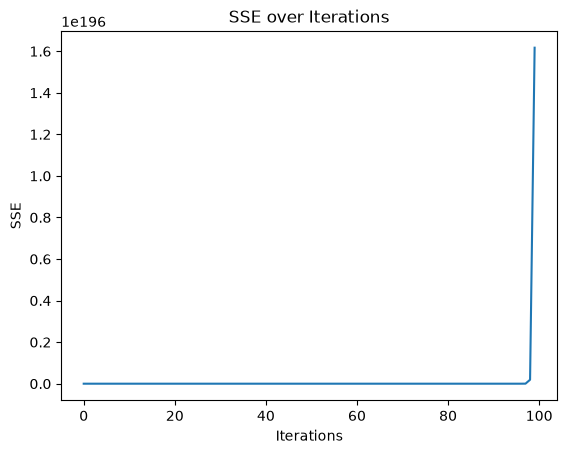

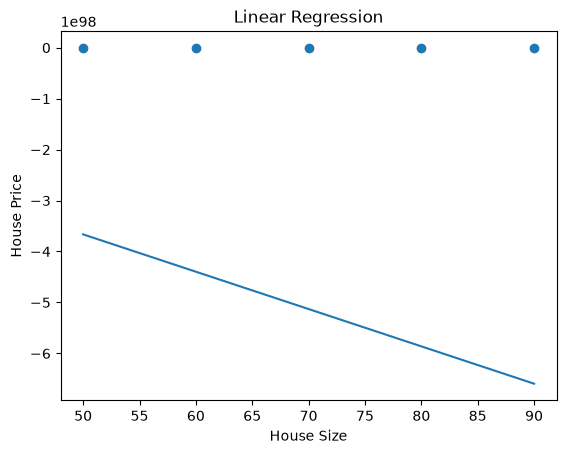

In [42]:
model.plot_training(X, y)

## Why SSE decreases over time


## لأن الـ Gradient Descent الهدف منها هو تقليل نسبة الغلط ففي كل لفة الموديل بيحسب الغلط بين السعراللي المودل طلعه والسعر الحقيقي ويعدل قيم theta_0 و1_theta في الاتجاه اللي يقلل الخطأ ده ومع استمرار التعديل في كل لفة، إجمالي الغلط بيفضل يقل بالتدريج لحد ما الموديل يوصل لأفضل خط مستقيم ويستقر دا اللي المفروض كان يحصل بس في الرسمه طالعه لفوق فا كدا ال sse زاد مقلش دا بسبب ان ال rate اللي حضرتك حاطه في المودل كبير جدا على الداتا فا بدال ما يقل زاد 

## What convergence means in Gradient Descent

## معناها الموديل وصل ل اقل نسبه غلط يقدر يعملها وقيم سيتا 0 وسيتا 1 مبقتش بتتغير فا بالتالي ال sse ثبت 

In [43]:
large_lr_model = LinearRegressionGD(lr=0.00001, n_iters=100)
large_lr_model.sse_history = large_lr_model.sh
large_lr_model.fit(X, y)
print("Large learning rate")
print("theta_0 =", large_lr_model.theta_0)
print("theta_1 =", large_lr_model.theta_1)
print("SSE =", large_lr_model.sse_history[-1])

Large learning rate
theta_0 = 0.04116492950170943
theta_1 = 2.9993713328364127
SSE = 0.00046041150816733306


In [44]:
small_lr_model = LinearRegressionGD(lr=0.000001, n_iters=100)
small_lr_model.fit(X, y)

print("Small learning rate")
print("theta_0 =", small_lr_model.theta_0)
print("theta_1 =", small_lr_model.theta_1)
print("SSE =", small_lr_model.sh[-1])

Small learning rate
theta_0 = 0.026403782164981494
theta_1 = 1.923712864802833
SSE = 30130.80602713573


## What happens if the learning rate is too large?

In [45]:
## لو الألفا كبيرة الموديل هيعدي النقطة الصح ويحصل overshoot فبدال ما الخطأ يقل هتلاقيه بيزيد ويطير لفوق زي الرسمة بالضبط

In [46]:
"""

1 Convergence Speed
الألفا الكبيرة خلت الموديل يوصل أسرع بكتير إنما الألفا الصغيرة كانت بطيئة جدا ومحتاجة لفات أكتر عشان توصل للحل

2 Final SSE Value
الألفا الكبيرة طلعت نسبة خطأ صغيرة جدا 0.00046 يعني وصلت لاقل قيمة لكن الألفا الصغيرة مطلعاها رقم كبير 30130.8 لأن الموديل كان بطيء ولسه موصلش لأقل نقطة
"""

'\n\n1 Convergence Speed\nالألفا الكبيرة خلت الموديل يوصل أسرع بكتير إنما الألفا الصغيرة كانت بطيئة جدا ومحتاجة لفات أكتر عشان توصل للحل\n\n2 Final SSE Value\nالألفا الكبيرة طلعت نسبة خطأ صغيرة جدا 0.00046 يعني وصلت لاقل قيمة لكن الألفا الصغيرة مطلعاها رقم كبير 30130.8 لأن الموديل كان بطيء ولسه موصلش لأقل نقطة\n'

In [47]:
class MultipleLinearRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for i in range(self.epochs):
            y_pred = np.dot(X, self.weights) + self.bias
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [50]:
model = MultipleLinearRegression()
X = X.reshape(-1, 1)
model = MultipleLinearRegression(lr=1e-5, epochs=5000)
model.fit(X, y)
predictions = model.predict(X)
print(predictions)

[150.01289026 180.00725063 210.00161101 239.99597138 269.99033175]
